Data Cleaning & Preparation – Online Retail II

SWYNEX Technologies – Data Analytics Internship | Task 1

Objective: Clean, validate, and prepare the UCI Online Retail II dataset for further data analysis.

Tools: Python • Pandas • NumPy • Jupyter Notebook

What this notebook covers
1. Dataset loading and overview
2. Data quality assessment
3. Missing-value analysis
4. Duplicate and invalid-value analysis
5. Business-aware cleaning decisions
6. Feature engineering
7. Final validation
8. Cleaning summary and export
Dataset source: UCI Machine Learning Repository – Online Retail II

1. Import Libraries

We begin by importing the libraries required for data loading, cleaning, analysis, and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


2. Load the Dataset

The Online Retail II dataset is provided as an Excel workbook containing two sheets:
- Year 2009-2010
- Year 2010-2011
Both sheets are combined into a single DataFrame for the complete analysis.

In [3]:
# Project paths
file_path = Path("../data/raw/online_retail_II.xlsx")

# Load both sheets
excel_file = pd.ExcelFile(file_path)

print("Available sheets:")
print(excel_file.sheet_names)

df_2009_2010 = pd.read_excel(file_path, sheet_name="Year 2009-2010")
df_2010_2011 = pd.read_excel(file_path, sheet_name="Year 2010-2011")

# Combine both years
df = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)

print(f"\nCombined dataset shape: {df.shape}")

Available sheets:
['Year 2009-2010', 'Year 2010-2011']

Combined dataset shape: (1067371, 8)


3. Initial Dataset Overview

Before modifying the data, we inspect its structure, sample records, data types, and missing values.
This establishes a baseline against which the cleaned dataset can later be compared.

In [4]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
display(df.head())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset Information:")
df.info()

Dataset Shape: (1067371, 8)

Column Names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 Records:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



Data Types:


,Data Type
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[us]
Price,float64
Customer ID,float64
Country,str



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


4. Data Quality Assessment

The following checks are performed before cleaning:
- Missing values
- Exact duplicate records
- Negative quantities
- Zero and negative prices
- Cancellation invoices
- Potentially recoverable product descriptions
The goal is to understand the data before deciding what should and should not be removed.

In [5]:
# Missing values
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

display(missing_summary[missing_summary["Missing Count"] > 0].sort_values(
    "Missing Count", ascending=False
))

# Exact duplicates
duplicate_count = df.duplicated().sum()

# Transaction checks
negative_quantity_count = (df["Quantity"] < 0).sum()
zero_quantity_count = (df["Quantity"] == 0).sum()
zero_price_count = (df["Price"] == 0).sum()
negative_price_count = (df["Price"] < 0).sum()

print(f"Exact duplicate records : {duplicate_count:,}")
print(f"Negative quantities     : {negative_quantity_count:,}")
print(f"Zero quantities         : {zero_quantity_count:,}")
print(f"Zero prices             : {zero_price_count:,}")
print(f"Negative prices         : {negative_price_count:,}")

,Missing Count,Missing Percentage
Customer ID,243007,22.77
Description,4382,0.41


Exact duplicate records : 34,335
Negative quantities     : 22,950
Zero quantities         : 0
Zero prices             : 6,202
Negative prices         : 5


5. Investigating Negative Quantities

Negative quantities are not automatically treated as errors.

In retail transaction data, they can represent cancellations, returns, or operational adjustments. Therefore, these records are investigated before making a cleaning decision.

In [6]:
# Identify cancellation invoices
invoice_as_text = df["Invoice"].astype(str)
is_cancellation = invoice_as_text.str.startswith("C")

negative_quantity_analysis = pd.Series({
    "Negative quantity records": (df["Quantity"] < 0).sum(),
    "Negative quantities with cancellation invoice": (
        (df["Quantity"] < 0) & is_cancellation
    ).sum(),
    "Negative quantities without cancellation invoice": (
        (df["Quantity"] < 0) & (~is_cancellation)
    ).sum(),
    "Total cancellation invoices": is_cancellation.sum()
})

display(negative_quantity_analysis.to_frame("Count"))

print("\nExamples of negative-quantity records without cancellation invoices:")
display(
    df.loc[
        (df["Quantity"] < 0) & (~is_cancellation),
        ["Invoice", "StockCode", "Description", "Quantity", "Price"]
    ].head(10)
)

,Count
Negative quantity records,22950
Negative quantities with cancellation invoice,19493
Negative quantities without cancellation invoice,3457
Total cancellation invoices,19494



Examples of negative-quantity records without cancellation invoices:


,Invoice,StockCode,Description,Quantity,Price
263,489464,21733,85123a mixed,-96,0.0
283,489463,71477,short,-240,0.0
284,489467,85123A,21733 mixed,-192,0.0
470,489521,21646,NaN,-50,0.0
3114,489655,20683,NaN,-44,0.0
3162,489660,35956,lost,-1043,0.0
3168,489663,35605A,damages,-117,0.0
4296,489806,18010,NaN,-770,0.0
4538,489820,21133,invcd as 84879?,-720,0.0
4566,489821,85049G,NaN,-240,0.0


Cleaning Decision

Negative quantities are retained because they can carry meaningful information about cancellations, returns, damages, and other operational adjustments.

Instead of deleting them, they will be classified using a new TransactionType field.

6. Investigating Zero and Negative Prices

Zero-price records can represent free items, promotional transactions, adjustments, or operational records. They are therefore retained and flagged.

The five negative-price records are associated with "Adjust bad debt" and are treated as accounting adjustments rather than normal retail sales.

In [7]:
# Zero-price records
zero_price_rows = df[df["Price"] == 0].copy()

print(f"Zero-price records: {len(zero_price_rows):,}")

print("\nCommon descriptions among zero-price records:")
display(
    zero_price_rows["Description"]
    .value_counts(dropna=False)
    .head(10)
    .to_frame("Count")
)

# Negative-price records
negative_price_rows = df[df["Price"] < 0].copy()

print(f"\nNegative-price records: {len(negative_price_rows):,}")

display(
    negative_price_rows[
        ["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID", "Country"]
    ]
)

Zero-price records: 6,202

Common descriptions among zero-price records:


,Count
Description,
NaN,4382
check,162
?,92
damages,84
damaged,81
found,28
missing,27
sold as set on dotcom,20
Damaged,17



Negative-price records: 5


,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,-11062.06,NaN,United Kingdom


7. Cleaning the Dataset

Cleaning rules

| Data issue | Action |
|---|---|
| Exact duplicate rows | Remove |
| Missing descriptions | Recover using StockCode where possible |
| Remaining missing descriptions | Retain |
| Missing Customer IDs | Retain |
| Negative prices | Remove the 5 accounting-adjustment records |
| Zero prices | Retain and flag |
| Negative quantities | Retain and classify |
| InvoiceDate | Convert/validate as datetime |


These decisions are designed to preserve useful business information rather than deleting unusual records blindly.

In [8]:
# Keep a copy of the original dataset for comparison
df_raw = df.copy()

# 1. Remove exact duplicate records
df_clean = df_raw.drop_duplicates().copy()

# 2. Recover missing descriptions using StockCode
description_lookup = (
    df_clean.dropna(subset=["Description"])
            .drop_duplicates("StockCode")
            .set_index("StockCode")["Description"]
)

missing_description_before = df_clean["Description"].isna().sum()

df_clean["Description"] = (
    df_clean["Description"]
    .fillna(df_clean["StockCode"].map(description_lookup))
)

missing_description_after_recovery = df_clean["Description"].isna().sum()
recovered_descriptions = (
    missing_description_before - missing_description_after_recovery
)

# 3. Remove negative-price accounting adjustments
negative_price_removed = (df_clean["Price"] < 0).sum()
df_clean = df_clean[df_clean["Price"] >= 0].copy()

# 4. Standardize data types
df_clean["Customer ID"] = df_clean["Customer ID"].astype("Int64")
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

print("Cleaning steps completed.")
print(f"Exact duplicates removed: {df_raw.duplicated().sum():,}")
print(f"Descriptions recovered: {recovered_descriptions:,}")
print(f"Negative-price records removed: {negative_price_removed:,}")

Cleaning steps completed.
Exact duplicates removed: 34,335
Descriptions recovered: 3,912
Negative-price records removed: 5


8. Feature Engineering

Additional fields are created to make the cleaned dataset more useful for Exploratory Data Analysis and dashboard development.

New features
- IsCancellation – identifies invoices beginning with C
- IsZeroPrice – flags zero-price transactions
- TransactionType – Sale, Cancellation/Return, or Adjustment
- Revenue – Quantity × Price
- Year
- Month
- MonthName
- YearMonth

In [9]:
# Cancellation flag
df_clean["IsCancellation"] = (
    df_clean["Invoice"].astype(str).str.startswith("C")
)

# Zero-price flag
df_clean["IsZeroPrice"] = df_clean["Price"].eq(0)

# Transaction classification
df_clean["TransactionType"] = "Sale"

df_clean.loc[
    df_clean["IsCancellation"],
    "TransactionType"
] = "Cancellation/Return"

df_clean.loc[
    (df_clean["Quantity"] < 0) & (~df_clean["IsCancellation"]),
    "TransactionType"
] = "Adjustment"

# Revenue
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["Price"]

# Date features
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["MonthName"] = df_clean["InvoiceDate"].dt.month_name()
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)

print("Feature engineering completed.")

display(df_clean.head())

Feature engineering completed.


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancellation,IsZeroPrice,TransactionType,Revenue,Year,Month,MonthName,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,False,Sale,83.4,2009,12,December,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,Sale,81.0,2009,12,December,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,Sale,81.0,2009,12,December,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,False,Sale,100.8,2009,12,December,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,False,Sale,30.0,2009,12,December,2009-12


9. Transaction Type Distribution

The cleaned dataset distinguishes normal sales from cancellations/returns and other negative-quantity adjustments.

,Transaction Type,Record Count
0,Sale,1010534
1,Cancellation/Return,19104
2,Adjustment,3393


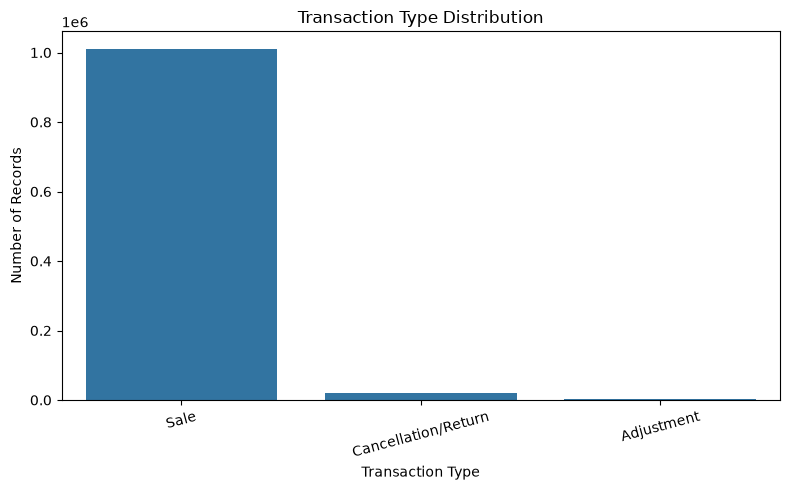

In [10]:
transaction_summary = (
    df_clean["TransactionType"]
    .value_counts()
    .rename_axis("Transaction Type")
    .reset_index(name="Record Count")
)

display(transaction_summary)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=transaction_summary,
    x="Transaction Type",
    y="Record Count"
)
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

10. Final Dataset Summary

The following comparison shows the impact of the cleaning process.

In [11]:
original_records = len(df_raw)
final_records = len(df_clean)
records_removed = original_records - final_records
retention_rate = (final_records / original_records) * 100

cleaning_summary = pd.DataFrame({
    "Metric": [
        "Original Records",
        "Final Records",
        "Records Removed",
        "Data Retention Rate",
        "Exact Duplicates Removed",
        "Negative Price Records Removed",
        "Missing Customer IDs",
        "Missing Descriptions",
        "Recovered Descriptions",
        "Zero Price Records",
        "Negative Quantity Records",
        "Cancellation/Return Records",
        "Adjustment Records",
        "Sale Records"
    ],
    "Value": [
        original_records,
        final_records,
        records_removed,
        f"{retention_rate:.2f}%",
        df_raw.duplicated().sum(),
        negative_price_removed,
        df_clean["Customer ID"].isna().sum(),
        df_clean["Description"].isna().sum(),
        recovered_descriptions,
        df_clean["IsZeroPrice"].sum(),
        (df_clean["Quantity"] < 0).sum(),
        (df_clean["TransactionType"] == "Cancellation/Return").sum(),
        (df_clean["TransactionType"] == "Adjustment").sum(),
        (df_clean["TransactionType"] == "Sale").sum()
    ]
})

display(cleaning_summary)

,Metric,Value
0,Original Records,1067371
1,Final Records,1033031
2,Records Removed,34340
3,Data Retention Rate,96.78%
4,Exact Duplicates Removed,34335
5,Negative Price Records Removed,5
6,Missing Customer IDs,235146
7,Missing Descriptions,363
8,Recovered Descriptions,3912
9,Zero Price Records,6014


11. Final Validation

A final validation step ensures that the cleaned dataset meets the intended quality requirements.

We verify:
- No exact duplicates remain
- No negative prices remain
- Dates are valid
- Revenue has no missing values
- Remaining missing descriptions are documented
- Missing Customer IDs are retained intentionally

In [12]:
validation_results = pd.Series({
    "Duplicate records": df_clean.duplicated().sum(),
    "Negative prices": (df_clean["Price"] < 0).sum(),
    "Missing InvoiceDate": df_clean["InvoiceDate"].isna().sum(),
    "Missing Revenue": df_clean["Revenue"].isna().sum(),
    "Missing Descriptions": df_clean["Description"].isna().sum(),
    "Missing Customer IDs": df_clean["Customer ID"].isna().sum(),
    "Zero-price records": df_clean["IsZeroPrice"].sum(),
    "Negative-quantity records": (df_clean["Quantity"] < 0).sum()
})

display(validation_results.to_frame("Count"))

assert df_clean.duplicated().sum() == 0
assert (df_clean["Price"] < 0).sum() == 0
assert df_clean["InvoiceDate"].isna().sum() == 0
assert df_clean["Revenue"].isna().sum() == 0

print("✓ Final validation passed successfully.")

,Count
Duplicate records,0
Negative prices,0
Missing InvoiceDate,0
Missing Revenue,0
Missing Descriptions,363
Missing Customer IDs,235146
Zero-price records,6014
Negative-quantity records,22496


✓ Final validation passed successfully.


12. Export the Cleaned Dataset

The cleaned dataset is saved for use in the next internship tasks, including Exploratory Data Analysis and dashboard development.

In [13]:
# Create output directories if they do not exist
cleaned_dir = Path("../data/cleaned")
output_dir = Path("../output")

cleaned_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

# Export cleaned dataset
cleaned_file = cleaned_dir / "online_retail_II_cleaned.csv"
summary_file = output_dir / "cleaning_summary.csv"

df_clean.to_csv(cleaned_file, index=False)
cleaning_summary.to_csv(summary_file, index=False)

print(f"Cleaned dataset saved to: {cleaned_file}")
print(f"Cleaning summary saved to: {summary_file}")

Cleaned dataset saved to: ..\data\cleaned\online_retail_II_cleaned.csv
Cleaning summary saved to: ..\output\cleaning_summary.csv


Final Project Outcome

Dataset preparation completed successfully

| Metric | Result |
|---|---:|
| Original records | **1,067,371** |
| Final records | **1,033,031** |
| Records removed | **34,340** |
| Data retention | **96.78%** |
| Duplicate records removed | **34,335** |
| Negative-price records removed | **5** |
| Descriptions recovered | **4,019** |


Key learning

The cleaning process demonstrated that data cleaning is not simply about deleting unusual records. Each anomaly should be investigated and classified based on its business meaning.

The resulting dataset is structured, validated, and ready for the next stage of the SWYNEX Technologies internship: Exploratory Data Analysis (EDA).